# Diabetes Prediction System Using Machine Learning
### By Pritesh Raj | Roll No: 230103035
### IIIT Senapati, Manipur

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('diabetes.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('Dataset size:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

Dataset size: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome Count:
Outcome
0    500
1    268
Name: count, dtype: int64

Non-Diabetic: 500 (65.1%)
Diabetic: 268 (34.9%)


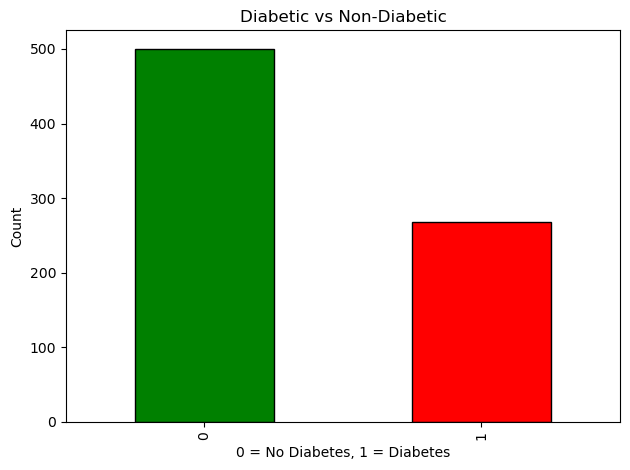

In [4]:
# Class distribution
print('Outcome Count:')
print(df['Outcome'].value_counts())
print(f'\nNon-Diabetic: {500} (65.1%)')
print(f'Diabetic: {268} (34.9%)')

df['Outcome'].value_counts().plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Diabetic vs Non-Diabetic')
plt.xlabel('0 = No Diabetes, 1 = Diabetes')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

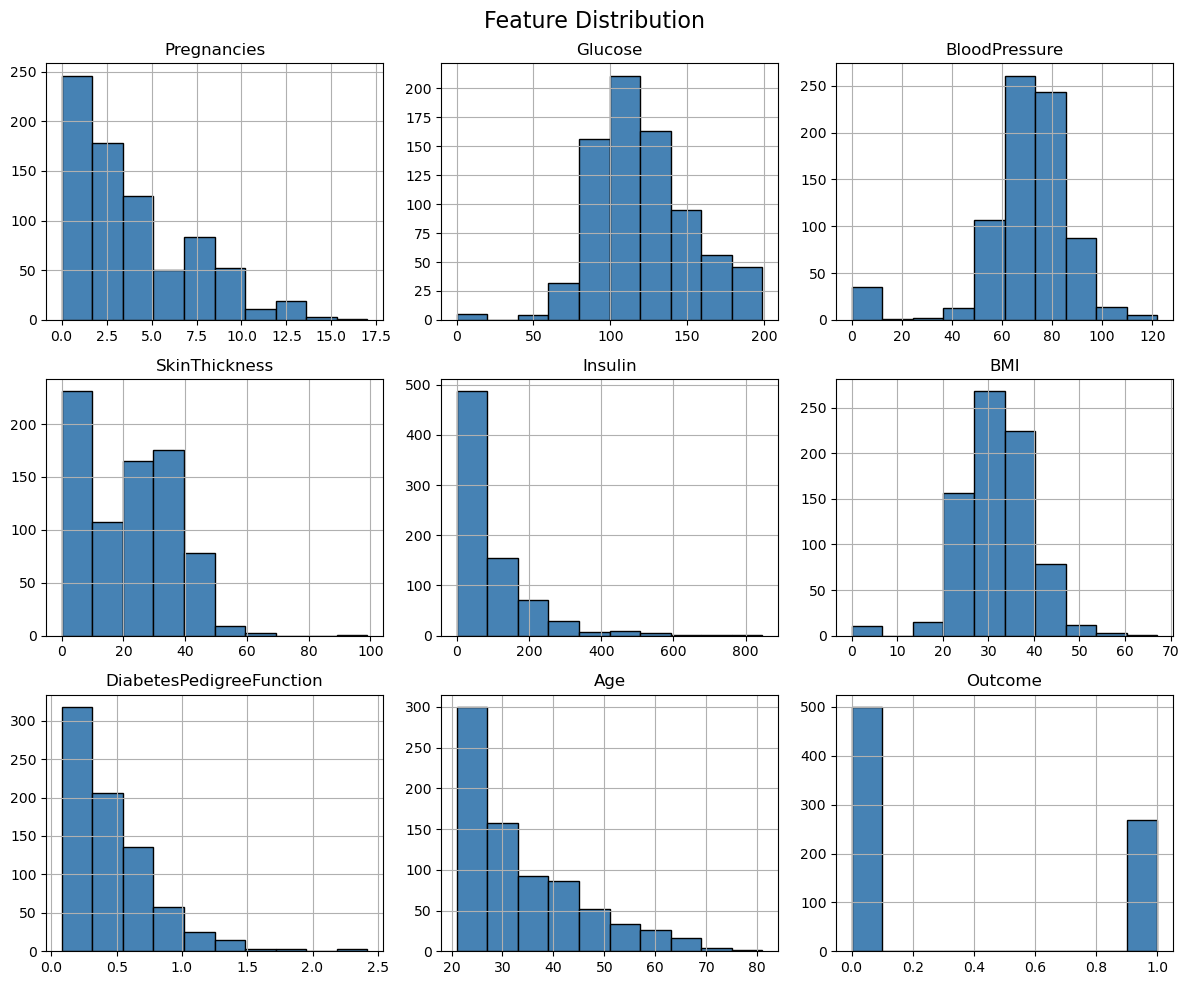

In [5]:
# Feature distribution
df.hist(figsize=(12, 10), color='steelblue', edgecolor='black')
plt.suptitle('Feature Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('fig2_feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

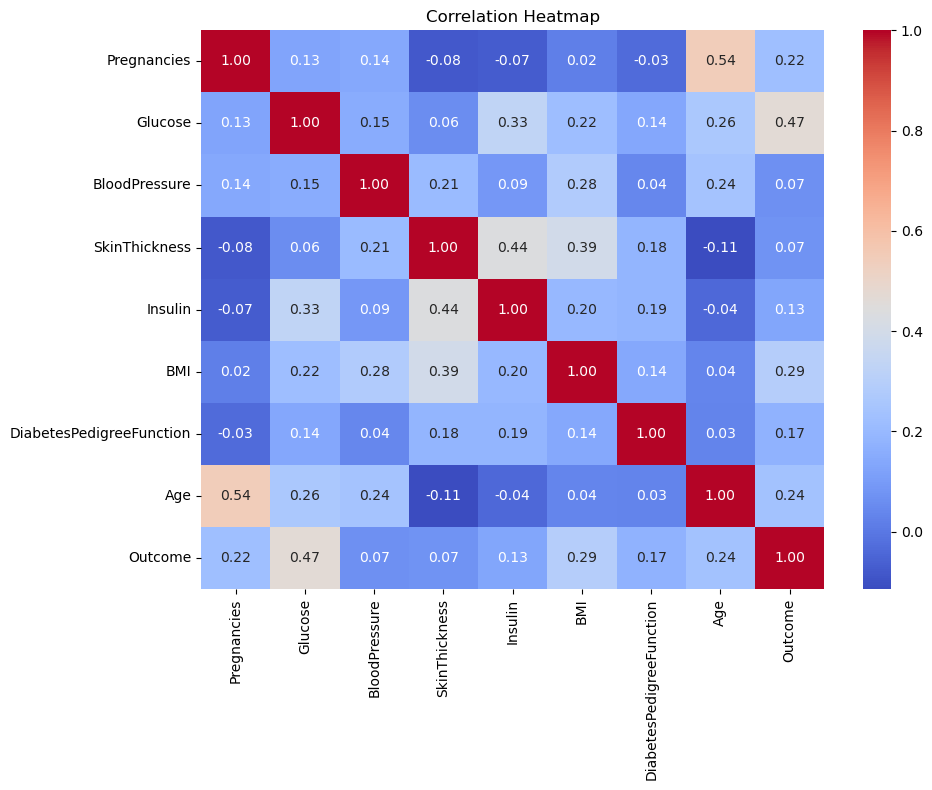

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

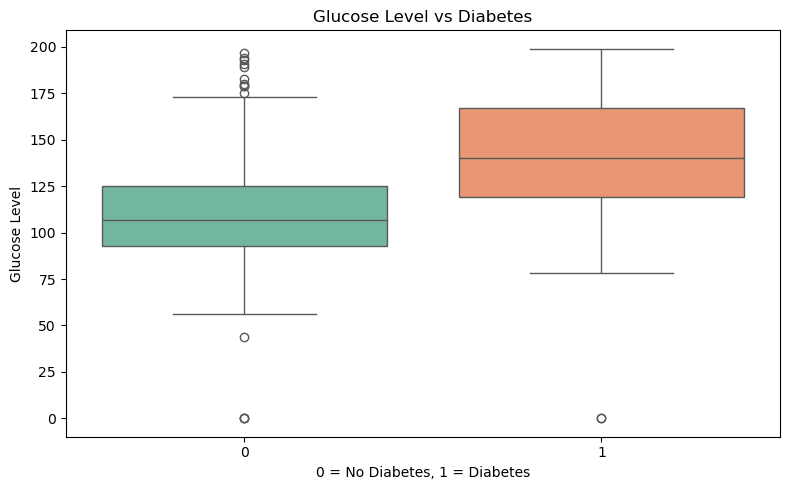

In [7]:
# Glucose vs Diabetes Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')
plt.title('Glucose Level vs Diabetes')
plt.xlabel('0 = No Diabetes, 1 = Diabetes')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.savefig('fig4_glucose_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Data Cleaning (Missing Value Treatment)

In [8]:
# Check zero values in clinical columns
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero values before cleaning:')
for col in cols:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} zeros')

# Replace zeros with column mean
for col in cols:
    df[col] = df[col].replace(0, df[col].mean())

print('\nZero values after cleaning:')
for col in cols:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} zeros')
print('\nData cleaning complete!')

Zero values before cleaning:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros

Zero values after cleaning:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros

Data cleaning complete!


## Step 5: Feature Engineering & Data Preparation

In [9]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train_scaled.shape[0]}')
print(f'Testing samples:  {X_test_scaled.shape[0]}')
print('Data preparation complete!')

Training samples: 614
Testing samples:  154
Data preparation complete!


## Step 6: Handle Class Imbalance using SMOTE

In [10]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {len(X_train_scaled)} samples')
print(f'After SMOTE:  {len(X_train_sm)} samples')
print(f'\nClass distribution after SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Before SMOTE: 614 samples
After SMOTE:  800 samples

Class distribution after SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


## Step 7: Train and Compare All ML Models

In [11]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   min_samples_split=5, random_state=42),
    'SVM':                 SVC(C=1.0, kernel='rbf', gamma='scale',
                               probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, random_state=42,
                                          eval_metric='logloss', verbosity=0),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                                       learning_rate=0.01,
                                                       subsample=0.7, random_state=42),
    'Voting Ensemble':     VotingClassifier(
                               estimators=[
                                   ('rf',  RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
                                   ('gb',  GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                                                       learning_rate=0.01, subsample=0.7, random_state=42)),
                                   ('xgb', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                                          subsample=0.8, colsample_bytree=0.8,
                                                          random_state=42, eval_metric='logloss', verbosity=0)),
                                   ('lr',  LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
                                   ('svm', SVC(C=1.0, kernel='rbf', gamma='scale',
                                               probability=True, random_state=42))
                               ],
                               voting='soft'
                           )
}

# Train and evaluate all models
results = {}
cv_results = {}
print('Training all models...')
print('='*55)

for name, model in models.items():
    # Train on SMOTE data
    model.fit(X_train_sm, y_train_sm)
    # Test accuracy
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    # Cross validation (5-fold)
    cv = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='accuracy')
    cv_results[name] = cv.mean()
    print(f'{name:<22} Test: {acc*100:.2f}%  |  CV: {cv.mean()*100:.2f}%')

print('='*55)
best_model_name = max(results, key=results.get)
print(f'Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)')

Training all models...
Logistic Regression    Test: 71.43%  |  CV: 73.37%
Random Forest          Test: 74.68%  |  CV: 79.50%
SVM                    Test: 72.73%  |  CV: 78.88%
KNN                    Test: 68.83%  |  CV: 81.63%
XGBoost                Test: 76.62%  |  CV: 78.88%
Gradient Boosting      Test: 74.68%  |  CV: 78.12%
Voting Ensemble        Test: 75.97%  |  CV: 79.12%
Best Model: XGBoost (76.62%)


## Step 8: Model Accuracy Comparison Graph

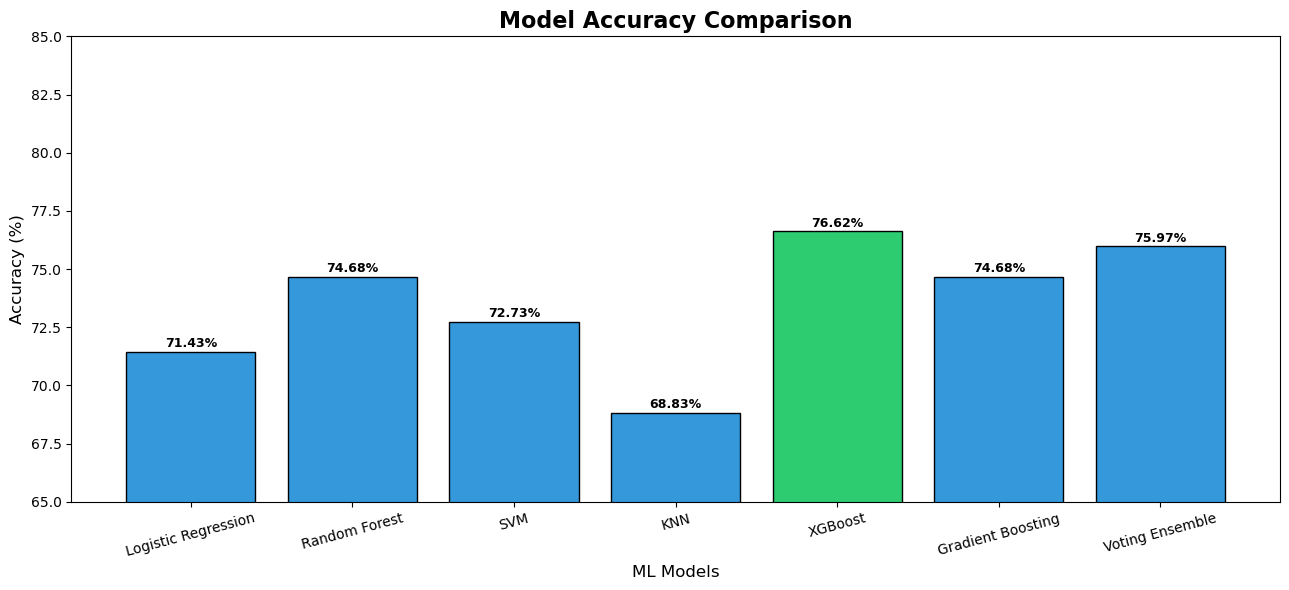

In [12]:
# Accuracy comparison bar chart
model_names = list(results.keys())
accuracies = [v * 100 for v in results.values()]
colors = ['#2ecc71' if v == max(accuracies) else '#3498db' for v in accuracies]

plt.figure(figsize=(13, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('ML Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim([65, 85])
plt.xticks(rotation=15)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Best Model - Detailed Analysis

In [13]:
# Use best model for final analysis
best_model = models[best_model_name]
y_pred_final = best_model.predict(X_test_scaled)

print(f'Best Model: {best_model_name}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print('='*55)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final,
      target_names=['No Diabetes', 'Diabetes']))

Best Model: XGBoost
Test Accuracy: 76.62%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.77      0.81       100
    Diabetes       0.64      0.76      0.69        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154



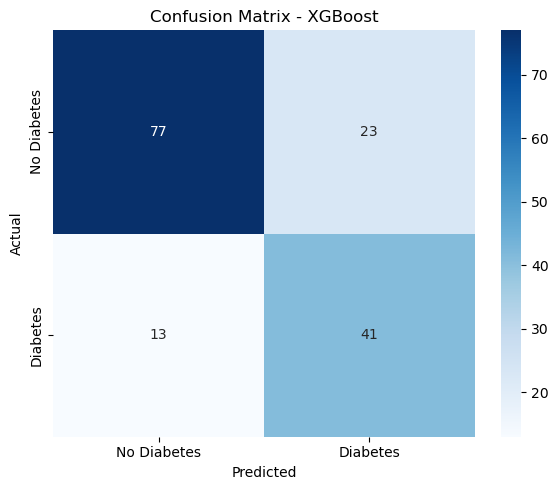

In [14]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('fig6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Save Final Model

In [16]:
# Save best model and scaler
pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print(f'Model saved: model.pkl ({best_model_name})')
print('Scaler saved: scaler.pkl')


Model saved: model.pkl (XGBoost)
Scaler saved: scaler.pkl
